# I. Suppliers all around the world: Who makes the most market supply!?


### A. Objectives:
In this notebook, we look at the Big Basket Data to give an insights whether what suppliers all around the world makes up the market supply around the world and how they control the market.

## II. Executive Summary 

&emsp;&emsp;This report provides a categorized role in the supply chain market regarding with the suppliers and it's categorized supplies. It was distrbibuted around the role. Methods of analysis include the qualitative insights from the data set provided.

&emsp;&emsp;The major areas of weakness require further investigation and action. Recommendations suggested include:
1. Under the category and suppliers look for the brand's well-known products.
2. Identify the average ratings per suppliers

## III. Data Description

### A. Data Source:
In this post, we will work on the dataset based on `Data Wrangling Exercise 1.xlsx` file.

Below are the data description that the grouped worked on:

1. suppliers— The manufacturer of the products of the brands in the market
2. category— The classifications of the products made by the different suppliers


## IV. Data Processing

In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('Data Wrangling Exercise 1.xlsx')
df

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description,estimated_profit_margin,stock_quantity,review_count,supplier,warehouse_location
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.00,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...,24.59,114.0,74.0,FreshFarm Ltd.,Mumbai
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.00,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ...",NaN,132.0,23.0,FreshFarm Ltd.,Hyderabad
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.00,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m...",11.48,116.0,33.0,DailyNeeds Supply,Bangalore
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.00,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...,17.88,113.0,22.0,DailyNeeds Supply,NaN
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.00,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...,18.89,111.0,38.0,GreenLeaf Distributors,Mumbai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27550,27551,"Wottagirl! Perfume Spray - Heaven, Classic",Beauty & Hygiene,Fragrances & Deos,Layerr,199.20,249.0,Perfume,3.9,Layerr brings you Wottagirl Classic fragrant b...,18.90,132.0,13.0,DailyNeeds Supply,Bangalore
27551,27552,Rosemary,Gourmet & World Food,Cooking & Baking Needs,Puramate,67.50,75.0,"Herbs, Seasonings & Rubs",4.0,Puramate rosemary is enough to transform a dis...,9.21,109.0,8.0,DailyNeeds Supply,Mumbai
27552,27553,Peri-Peri Sweet Potato Chips,Gourmet & World Food,"Snacks, Dry Fruits, Nuts",FabBox,200.00,200.0,Nachos & Chips,3.8,We have taken the richness of Sweet Potatoes (...,55.28,121.0,6.0,FreshFarm Ltd.,Mumbai
27553,27554,Green Tea - Pure Original,Beverages,Tea,Tetley,396.00,495.0,Tea Bags,4.2,"Tetley Green Tea with its refreshing pure, ori...",74.64,120.0,26.0,Urban Grocers,Mumbai


There are 27555 rows in the data with or without null values in the rows


As you can see there are many null values in the data set, thus we clean it by dropping the rows that is null

In [9]:
df_cleaned_any = df.dropna(subset=('supplier'))

df_cleaned_any

There are only **1391** null values in the suppliers column that is only **5.04808565%** of the data removed from the original data set.

In [14]:
df_cleaned_any.columns

Index(['index', 'product', 'category', 'sub_category', 'brand', 'sale_price',
       'market_price', 'type', 'rating', 'description',
       'estimated_profit_margin', 'stock_quantity', 'review_count', 'supplier',
       'warehouse_location'],
      dtype='str')

These are the columns in the data-set.

In [66]:
df2 = df_cleaned_any.groupby('supplier').count()['index'].reset_index()
df2

,supplier,index
0,DailyNeeds Supply,5230
1,FreshFarm Ltd.,7858
2,GreenLeaf Distributors,4038
3,Prime Retail Hub,2609
4,Urban Grocers,6429


We get the count of the different products under the different categories, listed in each suppliers.

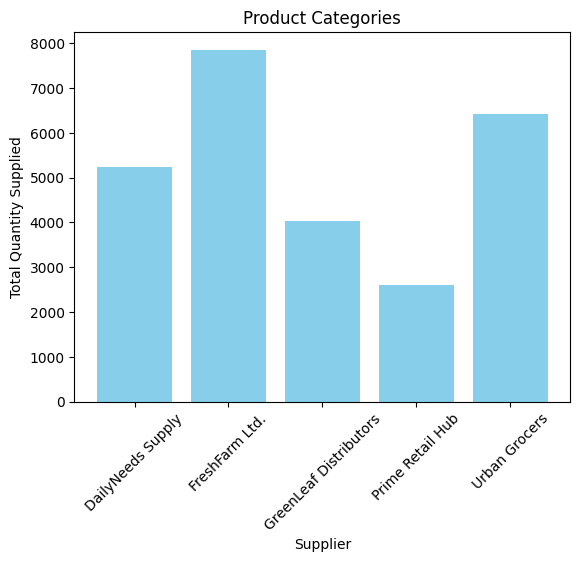

In [67]:
import matplotlib.pyplot as plt
import numpy as np

categories = df2['supplier']
values = df2['index']

plt.bar(categories, values, color='skyblue')

plt.xlabel("Supplier")
plt.ylabel("Total Quantity Supplied")
plt.title("Product Categories")

plt.xticks(rotation=45)
plt.show()


Out of *26164* entries of data in the supplier, it was grouped into different categories.

The leading supplier of the market all around the world is the **FreshFarm Ltd.**. Which has the total quantity of products amounting **7858**. The least supplier has the total quantity of products amounting to **2609** which is the **Prime Retail Hub**. 

In [16]:
df_cleaned_any.groupby(['supplier','category']).count()['index'].reset_index()

,supplier,category,index
0,DailyNeeds Supply,Baby Care,116
1,DailyNeeds Supply,"Bakery, Cakes & Dairy",156
2,DailyNeeds Supply,Beauty & Hygiene,1500
3,DailyNeeds Supply,Beverages,160
4,DailyNeeds Supply,Cleaning & Household,528
5,DailyNeeds Supply,"Eggs, Meat & Fish",67
6,DailyNeeds Supply,"Foodgrains, Oil & Masala",500
7,DailyNeeds Supply,Fruits & Vegetables,132
8,DailyNeeds Supply,Gourmet & World Food,884
9,DailyNeeds Supply,"Kitchen, Garden & Pets",643


We grouped and count the different suppliers with its count of the categorized products.

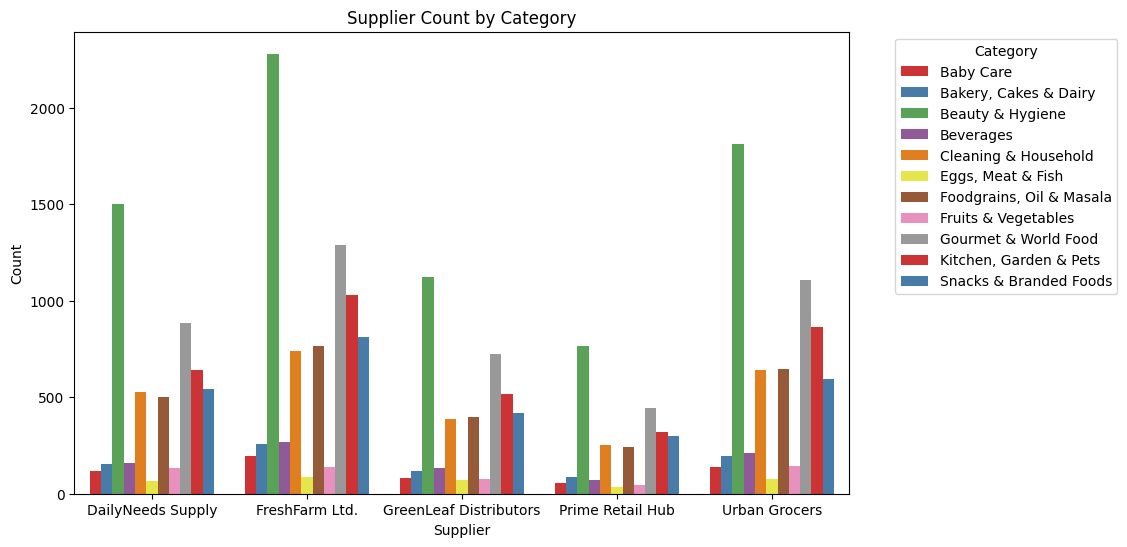

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming this is your data:
df_grouped = df_cleaned_any.groupby(['supplier','category']).count()['index'].reset_index()
# Optional: Rename the count column for clarity
df_grouped.rename(columns={'index': 'Count'}, inplace=True)
df_grouped.rename(columns={'supplier': 'Supplier'}, inplace=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_grouped, x='Supplier', y='Count', hue='category', palette='Set1' # This clusters by category
)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('Supplier Count by Category')
plt.show()


The highest products in each supplier is the **Beauty & Hygiene** next to it is **Gourmet & World Food**.

## V. Conclusion


&emsp;&emsp;We have analyzed the data report that from it's suppliers down to it's product categories. It is concluded that the **Beauty & Hygiene** is the most supplied products in the market - all around the world. **FreshFarm Ltd** is the leading supplier all around the world while next to it is **Urban Grocers**.